**REFER THE UPDATED DATASETS:**
- swiggy_raw_dataset_final
- swiggy_clean_dataset_final

In [ ]:
!pip install requests beautifulsoup4 pandas lxml

In [ ]:
import requests
import pandas as pd
import time

# Step 1 — City & Area Data with Lat/Long


city_areas_latlong = {

    # Bangalore
    "bangalore": [
        ("indiranagar", 12.971891, 77.641151),
        ("whitefield", 12.967995, 77.749955),
        ("koramangala", 12.935223, 77.624954),
        ("btm", 12.916527, 77.610116),
        ("hsr", 12.911559, 77.647822),
        ("marathahalli", 12.959138, 77.697403),
        ("jayanagar", 12.935193, 77.624207),
        ("rajajinagar", 13.022501, 77.549100),
        ("hebbal", 13.040555, 77.603333),
        ("bellandur", 12.916483, 77.689823),
        ("electronic-city", 12.839444, 77.677222),
        ("yelahanka", 13.100000, 77.590000),
        ("banashankari", 12.914169, 77.571133),
        ("basavanagudi", 12.949374, 77.570167),
        ("kalyan-nagar", 13.021687, 77.644020),
        ("sarjapur-road", 12.914129, 77.701081),
        ("jp-nagar", 12.915175, 77.587197),
        ("cv-raman-nagar", 13.025597, 77.701080),
        ("malleshwaram", 13.009405, 77.569233),
        ("kr-puram", 13.024548, 77.709679),
        ("frazer-town", 12.9987, 77.6143),
        ("ulsoor", 12.9833, 77.6220),
        ("bommanahalli", 12.9081, 77.6231),
        ("btm-2nd-stage", 12.9166, 77.6101),
        ("nagawara", 13.0358, 77.6245)
],

    # Chennai
    "chennai": [
        ("t-nagar", 13.041667, 80.236389),
        ("anna-nagar-east", 13.060440, 80.212006),
        ("velachery", 12.978000, 80.226780),
        ("adyar", 12.988334, 80.245117),
        ("porur", 13.033167, 80.163084),
        ("tambaram", 12.923025, 80.127653),
        ("ambattur", 13.106450, 80.152023),
        ("nungambakkam", 13.059820, 80.242570),
        ("perambur", 13.110743, 80.232132)
    ],

    # Hyderabad
    "hyderabad": [
        ("banjara-hills", 17.419585, 78.407558),
        ("jubilee-hills", 17.423970, 78.410391),
        ("madhapur", 17.447711, 78.391378),
        ("secunderabad", 17.439900, 78.498300),
        ("begumpet", 17.443116, 78.473226),
        ("kondapur", 17.441158, 78.356216),
        ("lb-nagar", 17.347950, 78.553680),
        ("gachibowli", 17.4401, 78.3489),
        ("kukatpally", 17.4948, 78.3996),
        ("ameerpet", 17.4375, 78.4482)
    ],

    "visakhapatnam": [
        ("mvp-colony", 17.7429, 83.3362),
        ("dwaraka-nagar", 17.7231, 83.3013),
        ("gajuwaka", 17.7006, 83.2033),
         ("seethammadhara", 17.7400, 83.3086)

      ],

    # Mumbai
    "mumbai": [
        ("andheri-west", 19.119550, 72.846900),
        ("bandra-west", 19.060000, 72.836100),
        ("powai", 19.117500, 72.904000),
        ("malad-west", 19.179437, 72.836757),
        ("borivali-west", 19.228117, 72.856015),
        ("thane", 19.218330, 72.978089),
        ("vashi", 19.078590, 73.017800),
        ("dadar", 19.018330, 72.842290),
        ("chembur", 19.0522, 72.9005),
        ("ghatkopar-east", 19.0800, 72.9080)
    ],

    # Delhi
    "delhi": [
        ("connaught-place", 28.631500, 77.216667),
        ("rajouri-garden", 28.646890, 77.100692),
        ("saket", 28.524578, 77.213130),
        ("lajpat-nagar-1", 28.566781, 77.256244),
        ("karol-bagh", 28.649294, 77.202977),
        ("janakpuri", 28.618740, 77.076320),
        ("pitampura", 28.710060, 77.114500),
        ("mayur-vihar-phase-1", 28.600031, 77.311916)
    ],

    # Kochi
    "kochi": [
        ("kakkanad", 10.015500, 76.330700),
        ("edappally", 10.023730, 76.311420),
        ("fort-kochi", 9.966667, 76.233333),
        ("kaloor", 10.016538, 76.315384),
        ("panampilly-nagar", 9.966389, 76.300000),
        ("tripunithura", 9.973290, 76.316430),
        ("vyttila", 9.980000, 76.288000),
        ("aluva", 10.107820, 76.351660),
        ("perumbavoor", 10.143200, 76.396800),
        ("kadavanthra", 9.966200, 76.289100)
    ],

    # Kolkata
    "kolkata": [
        ("park-street", 22.546170, 88.346440),
        ("salt-lake", 22.601630, 88.446510),
        ("new-town", 22.591510, 88.450160),
        ("howrah", 22.595770, 88.263610),
        ("dum-dum", 22.636720, 88.418550),
        ("jadavpur", 22.4973, 88.3691),
        ("ballygunge", 22.5205, 88.3656)
    ],

    # Pune
    "pune": [
        ("hinjawadi", 18.597340, 73.733000),
        ("baner", 18.559920, 73.774340),
        ("wakad", 18.603270, 73.743570),
        ("kothrud", 18.507110, 73.810340),
        ("viman-nagar", 18.567620, 73.914100),
        ("hadapsar", 18.5089, 73.9260),
        ("aundh", 18.5590, 73.8077),
        ("chinchwad", 18.6298, 73.7997),
        ("magarpatta", 18.5156, 73.9250)
           ],

    # Ahmedabad
    "ahmedabad": [
        ("navrangpura", 23.050000, 72.580000),
        ("satellite", 23.040000, 72.560000),
        ("bopal", 23.030000, 72.450000),
        ("vastrapur", 23.030000, 72.540000),
        ("nikol", 22.970000, 72.650000)
        ],

    # Jaipur
    "jaipur": [
        ("malviya-nagar", 26.879300, 75.795800),
        ("vaishali-nagar", 26.932000, 75.787000),
        ("mansarovar", 26.870400, 75.743000),
        ("tonk-road", 26.876000, 75.824000)
            ],

    # Trivandrum
    "trivandrum": [
        ("pattom", 8.503300, 76.939000),
        ("vazhuthacaud", 8.500000, 76.941000),
        ("kumarapuram", 8.531400, 76.911500),
        ("sreekariyam", 8.551200, 76.893200)
    ],


    # Mysore
    "mysore": [
        ("gokulam", 12.331600, 76.652400),
        ("vijay-nagar", 12.320000, 76.627700),
        ("jayalakshmipuram", 12.315200, 76.647200),
        ("kuvempunagar", 12.305500, 76.650600),
        ("chamrajpura", 12.300000, 76.650000)
    ],

    # Coimbatore
    "coimbatore": [
        ("rs-puram", 11.017200, 76.969900),
        ("gandhipuram", 11.023300, 76.956600),
        ("saibaba-colony", 10.992300, 76.961400),
        ("singanallur", 10.969000, 77.025300)
    ]

}


# Step 2 — Requests Session

session = requests.Session()
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json",
    "Referer": "https://www.swiggy.com/",
    "Origin": "https://www.swiggy.com"
}

# Visit homepage first
session.get("https://www.swiggy.com", headers=headers)
time.sleep(2)


# Step 3 — Storage


all_data = []


# Step 4 — Loop through cities and areas

for city, areas in city_areas_latlong.items():
    for area_name, lat, lng in areas:

        print(f"\nProcessing {city} - {area_name}")

        # Pagination
        for offset in range(0, 40, 20):

            swiggy_url = (
                "https://www.swiggy.com/dapi/restaurants/list/v5"
                f"?lat={lat}&lng={lng}"
                "&page_type=DESKTOP_WEB_LISTING"
                f"&offset={offset}"
            )

            try:
                response = session.get(swiggy_url, headers=headers)

                if response.status_code != 200:
                    print("⚠️ Status:", response.status_code)
                    continue

                try:
                    data = response.json()
                except:
                    print("⚠️ JSON decode failed")
                    continue

                cards = data.get("data", {}).get("cards", [])

                for card in cards:
                    try:
                        restaurant_list = card["card"]["card"]["gridElements"]["infoWithStyle"]["restaurants"]
                        for r in restaurant_list:
                            info = r["info"]

                            restaurant_id = info.get("id")
                            name = info.get("name")
                            link = f"https://www.swiggy.com/dapi/menu/pl?restaurantId={restaurant_id}"
                            area = info.get("areaName")
                            cuisine = ", ".join(info.get("cuisines", []))
                            rating = info.get("avgRating")
                            price = info.get("costForTwo")
                            delivery_time = info.get("sla", {}).get("deliveryTime")
                            ratings_string = info.get("totalRatingsString")
                            votes = ratings_string if ratings_string else "0"
                            has_online_delivery = 1 if delivery_time else 0
                            has_table_booking = 0  # As Swiggy delivery page it will be always 0

                            if name:
                                all_data.append([
                                    restaurant_id,name,link,city, area, cuisine, rating,
                                    votes, has_online_delivery, has_table_booking, price
                                ])
                    except:
                        pass

                print("Offset", offset, "Done | Total restaurants so far:", len(all_data))
                time.sleep(2)

            except Exception as e:
                print("Error:", e)


# Step 5 — Create DataFrame


df = pd.DataFrame(
    all_data,
    columns=[
        "restaurant_id","name","link", "city", "area", "cuisine", "rating",
        "votes", "has_online_delivery", "has_table_booking", "price"
    ]
)

# Step 6 — Save CSV


df.to_csv("swiggy.csv", index=False, encoding="utf-8-sig")

print("\nTotal Restaurants:", len(df))
print("✅ Dataset saved successfully!")


Processing bangalore - indiranagar
Offset 0 Done | Total restaurants so far: 28
Offset 20 Done | Total restaurants so far: 56

Processing bangalore - whitefield
Offset 0 Done | Total restaurants so far: 84
Offset 20 Done | Total restaurants so far: 112

Processing bangalore - koramangala
Offset 0 Done | Total restaurants so far: 140
Offset 20 Done | Total restaurants so far: 168

Processing bangalore - btm
Offset 0 Done | Total restaurants so far: 196
Offset 20 Done | Total restaurants so far: 224

Processing bangalore - hsr
Offset 0 Done | Total restaurants so far: 252
Offset 20 Done | Total restaurants so far: 280

Processing bangalore - marathahalli
Offset 0 Done | Total restaurants so far: 308
Offset 20 Done | Total restaurants so far: 336

Processing bangalore - jayanagar
Offset 0 Done | Total restaurants so far: 364
Offset 20 Done | Total restaurants so far: 392

Processing bangalore - rajajinagar
Offset 0 Done | Total restaurants so far: 420
Offset 20 Done | Total restaurants s

In [6]:
import pandas as pd
d=pd.read_csv('/content/swiggy.csv')

In [7]:
len(d)

6256

In [8]:
d_new = d.drop_duplicates()

print("Total rows (after duplicates removed):", len(d_new))

Total rows (after duplicates removed): 2043


In [9]:
old_df=pd.read_csv('/content/swiggy_raw_dataset.csv')

In [10]:
combined_df = pd.concat([old_df, d])

In [11]:
len(combined_df)

11398

In [12]:
combined_df=combined_df.drop('restaurant_id',axis=1)

In [13]:
combined_df.to_csv("swiggy_raw_dataset_final.csv", index=False, encoding="utf-8-sig")

# Exploratory Data Analysis

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/swiggy_raw_dataset_final.csv")

In [15]:
data.head()

,name,link,city,area,cuisine,rating,votes,has_online_delivery,has_table_booking,price
0,Pizza Hut,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,Pizzas,4.3,20K+,1,0,₹300 for two
1,Burger King,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Burgers, American",4.3,81K+,1,0,₹350 for two
2,Domino's Pizza,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Pizzas, Italian, Pastas, Desserts",4.3,22K+,1,0,₹400 for two
3,KFC,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,HAL 2nd stage,"Burgers, Fast Food, Rolls & Wraps",4.2,4.7K+,1,0,₹400 for two
4,McDonald's,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,"Ashwini Complex,Indiranagar","Burgers, Beverages, Cafe, Desserts",4.4,50K+,1,0,₹400 for two


In [16]:
data.tail()

,name,link,city,area,cuisine,rating,votes,has_online_delivery,has_table_booking,price
11393,Chinese Wok,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Peelamedu,"Chinese, Asian, Tibetan, Desserts",4.3,4.8K+,1,0,₹250 for two
11394,Big Bowl,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Namburar,"Chinese, Tibetan, Desserts",4.4,2.6K+,1,0,₹250 for two
11395,Hotel Vignesh,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,malumichampatti,"South Indian, Indian",4.5,3.0K+,1,0,₹100 for two
11396,MSR Biriyani Hotel,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Podanur,"Biryani, South Indian, Indian",4.3,21K+,1,0,₹350 for two
11397,D.R.Biriyani Sivaji Kadai,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Podanur,"Biryani, South Indian, Indian",4.6,2.4K+,1,0,₹300 for two


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11398 entries, 0 to 11397
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 11398 non-null  object 
 1   link                 11398 non-null  object 
 2   city                 11398 non-null  object 
 3   area                 11398 non-null  object 
 4   cuisine              11398 non-null  object 
 5   rating               11392 non-null  float64
 6   votes                11398 non-null  object 
 7   has_online_delivery  11398 non-null  int64  
 8   has_table_booking    11398 non-null  int64  
 9   price                11398 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 890.6+ KB


In [18]:
data.describe()

,rating,has_online_delivery,has_table_booking
count,11392.000000,11398.0,11398.0
mean,4.399043,1.0,0.0
std,0.227010,0.0,0.0
min,3.000000,1.0,0.0
25%,4.300000,1.0,0.0
50%,4.400000,1.0,0.0
75%,4.600000,1.0,0.0
max,5.000000,1.0,0.0


In [19]:
data.describe(include=['object','category'])

,name,link,city,area,cuisine,votes,price
count,11398,11398,11398,11398,11398,11398,11398
unique,746,2978,14,945,730,758,45
top,Pizza Hut,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Mysore South,Pizzas,10K+,₹400 for two
freq,754,24,2520,306,769,285,2736


In [20]:
data.shape

(11398, 10)

Target Column:**success**

**CLASSIFICATION PROBLEM**

**Problem Statement**:Predict whether a restaurant will be successful based on its characteristics.

In [21]:
# handling price column
data["price"] = data["price"].astype(str) # converting to string

data["price"] = (
    data["price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False) #not regular expression
    .str.extract(r"(\d+)")# extracting digit # + since more than one digit
)

data["price_for_two"] = pd.to_numeric(data["price"],errors="coerce")# string to number form and errors avoids if there is none or missing values to nan

In [22]:
def clean_votes(vote_str):

    vote_str = str(vote_str).strip().lower()

    # Missing / special cases
    if vote_str in ['-', 'new', '', 'nan', 'none']:
        return 0

    # Handle '<3'
    if vote_str.startswith('<'):
        vote_str = vote_str.replace('<', '')

    # Remove '+' sign
    vote_str = vote_str.replace('+', '')

    # Handle '1.2k'
    if 'k' in vote_str:
        vote_str = vote_str.replace('k', '')
        return int(float(vote_str) * 1000)

    # Try normal conversion
    try:
        return int(float(vote_str))
    except:
        return 0

In [23]:
data['votes'] = data['votes'].apply(clean_votes)

In [24]:
data.drop(columns=["price"], inplace=True)

In [25]:
#defining success metric
data["success"] = (data["rating"] >= 4.1).astype(int)

In [26]:
data["rating"].describe()

,rating
count,11392.000000
mean,4.399043
std,0.227010
min,3.000000
25%,4.300000
50%,4.400000
75%,4.600000
max,5.000000


In [27]:
data

,name,link,city,area,cuisine,rating,votes,has_online_delivery,has_table_booking,price_for_two,success
0,Pizza Hut,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,Pizzas,4.3,20000,1,0,300,1
1,Burger King,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Burgers, American",4.3,81000,1,0,350,1
2,Domino's Pizza,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Pizzas, Italian, Pastas, Desserts",4.3,22000,1,0,400,1
3,KFC,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,HAL 2nd stage,"Burgers, Fast Food, Rolls & Wraps",4.2,4700,1,0,400,1
4,McDonald's,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,"Ashwini Complex,Indiranagar","Burgers, Beverages, Cafe, Desserts",4.4,50000,1,0,400,1
...,...,...,...,...,...,...,...,...,...,...,...
11393,Chinese Wok,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Peelamedu,"Chinese, Asian, Tibetan, Desserts",4.3,4800,1,0,250,1
11394,Big Bowl,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Namburar,"Chinese, Tibetan, Desserts",4.4,2600,1,0,250,1
11395,Hotel Vignesh,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,malumichampatti,"South Indian, Indian",4.5,3000,1,0,100,1
11396,MSR Biriyani Hotel,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Podanur,"Biryani, South Indian, Indian",4.3,21000,1,0,350,1


In [28]:
data['success'].value_counts()

,count
success,
1,10683
0,715


In [29]:
data["cuisine_count"] = data["cuisine"].str.count(",") + 1

In [30]:
data

,name,link,city,area,cuisine,rating,votes,has_online_delivery,has_table_booking,price_for_two,success,cuisine_count
0,Pizza Hut,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,Pizzas,4.3,20000,1,0,300,1,1
1,Burger King,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Burgers, American",4.3,81000,1,0,350,1,2
2,Domino's Pizza,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,Indiranagar,"Pizzas, Italian, Pastas, Desserts",4.3,22000,1,0,400,1,4
3,KFC,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,HAL 2nd stage,"Burgers, Fast Food, Rolls & Wraps",4.2,4700,1,0,400,1,3
4,McDonald's,https://www.swiggy.com/dapi/menu/pl?restaurant...,bangalore,"Ashwini Complex,Indiranagar","Burgers, Beverages, Cafe, Desserts",4.4,50000,1,0,400,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
11393,Chinese Wok,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Peelamedu,"Chinese, Asian, Tibetan, Desserts",4.3,4800,1,0,250,1,4
11394,Big Bowl,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Namburar,"Chinese, Tibetan, Desserts",4.4,2600,1,0,250,1,3
11395,Hotel Vignesh,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,malumichampatti,"South Indian, Indian",4.5,3000,1,0,100,1,2
11396,MSR Biriyani Hotel,https://www.swiggy.com/dapi/menu/pl?restaurant...,coimbatore,Podanur,"Biryani, South Indian, Indian",4.3,21000,1,0,350,1,3


In [31]:
# null value checking
data.isnull().sum()

,0
name,0
link,0
city,0
area,0
cuisine,0
rating,6
votes,0
has_online_delivery,0
has_table_booking,0
price_for_two,0


In [32]:
# dropping link as they are just for information and not helpful in prediction
#dropping has_table_booking column since the data is taken from Swiggy's online delivery restaurant options page
# table booking option will be availabe only in dine out
# so values in it is 0 indicating its not availabe which is not important as we have has_online_delivery which conveys it
data= data.drop(columns=['link','has_table_booking'])

In [33]:
# dividing into numerical and categorical columns
num_col=data.select_dtypes(include=['int64','float64']).columns
num_col

Index(['rating', 'votes', 'has_online_delivery', 'price_for_two', 'success',
       'cuisine_count'],
      dtype='object')

In [34]:
cat_col=data.select_dtypes(include=['object','category']).columns
cat_col

Index(['name', 'city', 'area', 'cuisine'], dtype='object')

In [35]:
print("Total rows (with duplicates):", len(data))

df = data.drop_duplicates(subset=['name','city','area'])

print("Total rows (after duplicates removed):", len(df))

Total rows (with duplicates): 11398
Total rows (after duplicates removed): 2944


In [36]:
df['city'].value_counts()

,count
city,
bangalore,647
mumbai,341
chennai,281
delhi,276
hyderabad,258
pune,214
kochi,174
kolkata,167
ahmedabad,140


In [37]:
df['success'].value_counts()

,count
success,
1,2752
0,192


In [38]:
# visualizations
# univariate-hist,box plot

# bivariate
# any relationship plot for uderstanding

<Axes: ylabel='votes'>

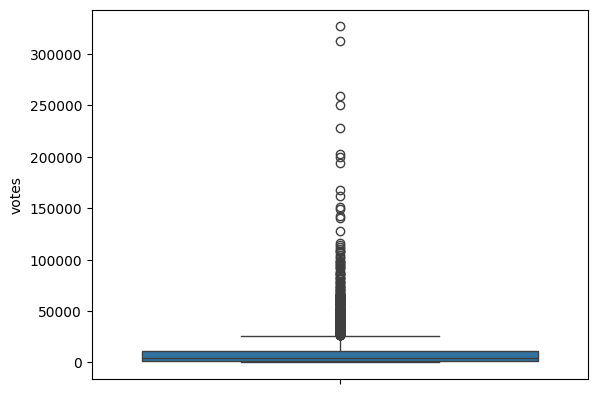

In [39]:
# outlier checking
sns.boxplot(df['votes'])

<Axes: ylabel='price_for_two'>

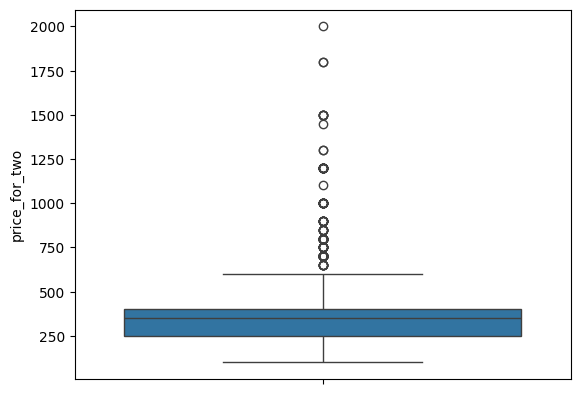

In [40]:
# outlier checking
sns.boxplot(df['price_for_two'])

Text(0, 0.5, 'count')

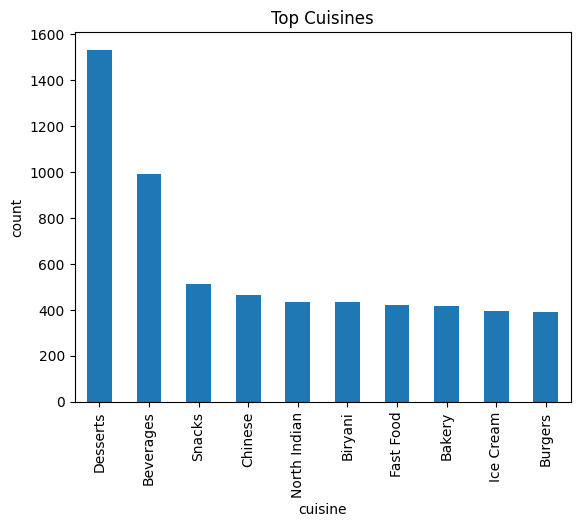

In [41]:
df['cuisine'].str.split(",").explode().str.strip().value_counts().head(10).plot(
    kind="bar",
    title="Top Cuisines"
)
plt.ylabel("count")
# explodes each cuisine as a separate row for each restaurant with all details same but each row only the cuisines will be different
# no. of rows will be how many cuisines are there in each restaurant

In [42]:
df['cuisine'].value_counts()

,count
cuisine,
"Burgers, Fast Food, Rolls & Wraps",115
Pizzas,107
"sandwich, Salads, wrap, Healthy Food",87
"Burgers, Beverages, Cafe, Desserts",85
"Chinese, Asian, Tibetan, Desserts",84
...,...
"Arabian, Tandoor",1
"Arabian, Lebanese, European",1
"Bakery, Italian",1


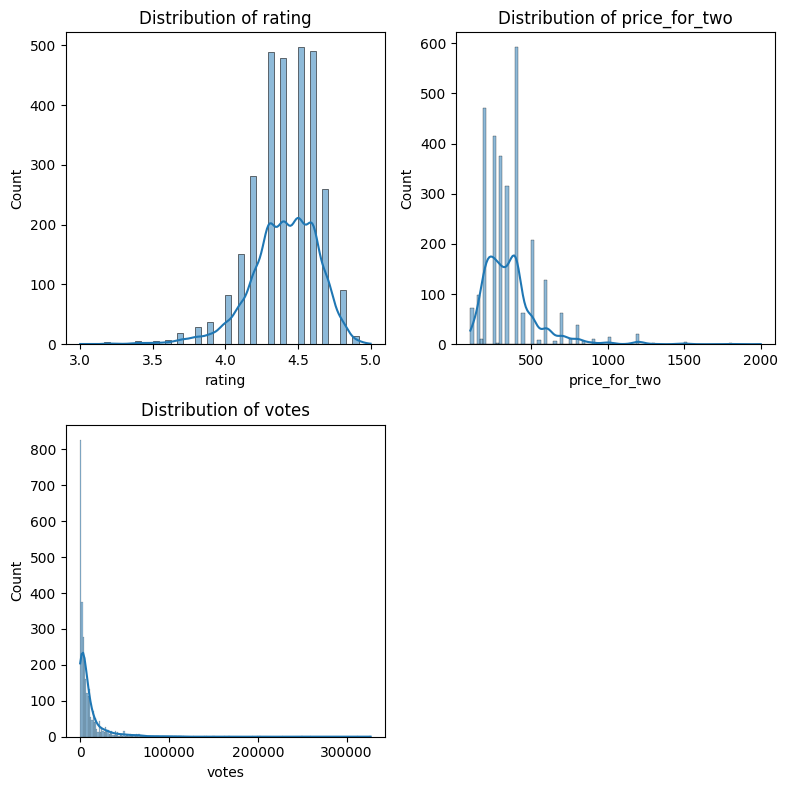

In [43]:
# distribution plots
columns=['rating','price_for_two','votes']
plt.figure(figsize=(8,8))
for i,col in enumerate(columns,1):
  plt.subplot(2,2,i)
  sns.histplot(df[col],kde=True)
  plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [44]:
# Top Rated Restaurants
top_restaurants = df.sort_values(by="rating",ascending=False).head(30)
top_restaurants

,name,city,area,cuisine,rating,votes,has_online_delivery,price_for_two,success,cuisine_count
3864,Royce' Chocolate,pune,Viman Nagar,Desserts,5.0,294,1,750,1,1
2067,Royce' Chocolate,mumbai,Bandra West,Desserts,4.9,1400,1,750,1,1
7282,Indulge Ice Cream By Almond House,hyderabad,Rasoolpura,Desserts,4.9,160,1,250,1,1
3295,Gourmet Ice Cream Cakes by Baskin Robbins,kochi,PERUMBAVOOR,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,9,1,200,1,4
2908,Gourmet Ice Cream Cakes by Baskin Robbins,kochi,Kakkanad,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,74,1,200,1,4
3822,Maks Kitchen,pune,Kothrud,Fast Food,4.9,34,1,200,1,1
3872,Gourmet Ice Cream Cakes by Baskin Robbins,pune,Viman Nagar,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,45,1,250,1,4
6559,Minus 30,chennai,T Nagar,"Ice Cream, Desserts, Waffle, Healthy Food, Cho...",4.9,499,1,280,1,5
1358,Gourmet Ice Cream Cakes by Baskin Robbins,chennai,Mahalakshmi Nagar,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,52,1,200,1,4
3073,Gourmet Ice Cream Cakes by Baskin Robbins,kochi,Kaloor,"Ice Cream Cakes, Desserts, Ice Cream, Bakery",4.9,216,1,250,1,4


In [45]:
# Top Popular Restaurants having high no.of votes
top_voted = df.sort_values(by="votes",ascending=False).head(30)
top_voted

,name,city,area,cuisine,rating,votes,has_online_delivery,price_for_two,success,cuisine_count
7116,Shah Ghouse Hotel & Restaurant,hyderabad,Tolichowki,"Biryani, Chinese, Mughlai, Tandoor",4.3,327000,1,350,1,4
7389,Lucky Restaurant,hyderabad,Nagole,"Biryani, Tandoor",4.2,313000,1,300,1,2
7277,Meridian Restaurant,hyderabad,Panjagutta,"Biryani, Chinese, Kebabs",4.4,259000,1,400,1,3
2913,Alakapuri,kochi,Kakkanad,"South Indian, Kerala",4.7,250000,1,300,1,2
7061,Shah Ghouse Hotel & Restaurant,hyderabad,Gachibowli,"Biryani, Chinese, Mughlai, Tandoor",4.3,228000,1,350,1,4
9615,Bachan's Dhaba,kolkata,South Kolkata,"North Indian, Chinese, Biryani, Beverages",4.6,203000,1,250,1,4
1805,Grill 9,hyderabad,Kharkhana & Trimulgherry,"Biryani, Chinese, Kebabs, Arabian, Lebanese",4.3,200000,1,400,1,5
1806,Paradise Biryani,hyderabad,Ramgopalpet,"Biryani, Kebabs, Hyderabadi, Rolls & Wraps",4.5,194000,1,400,1,4
7741,Grand Alpha(Original),visakhapatnam,Gajuwaka,"Indian, Tandoor, Biryani",4.4,168000,1,350,1,3
4196,DMB Sweets Pvt Ltd,jaipur,C scheme,"Jain, South Indian, Snacks, Bengali, Italian, ...",4.5,162000,1,350,1,6


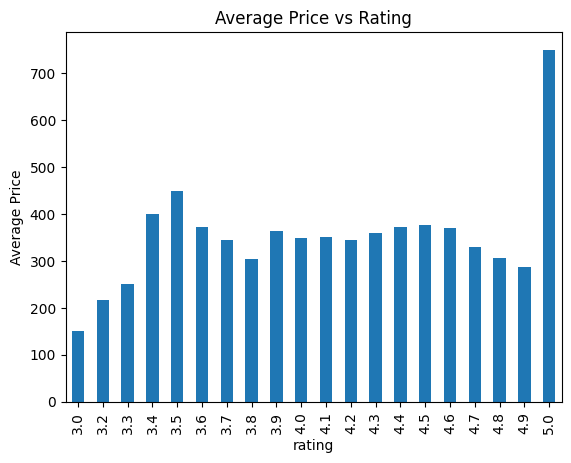

In [46]:
#Price vs Rating Relationship
df.groupby("rating")["price_for_two"].mean().plot(
    kind="bar",
    title="Average Price vs Rating"
)

plt.ylabel("Average Price")
plt.show()

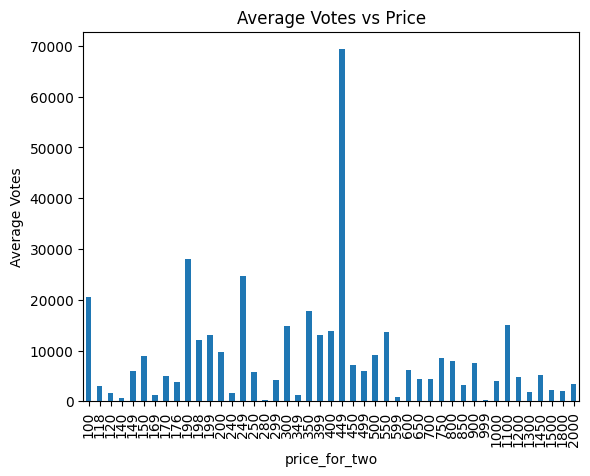

In [47]:
# Votes vs Price Relationship
df.groupby("price_for_two")["votes"].mean().plot(
    kind="bar",
    title="Average Votes vs Price"
)

plt.ylabel("Average Votes")
plt.show()

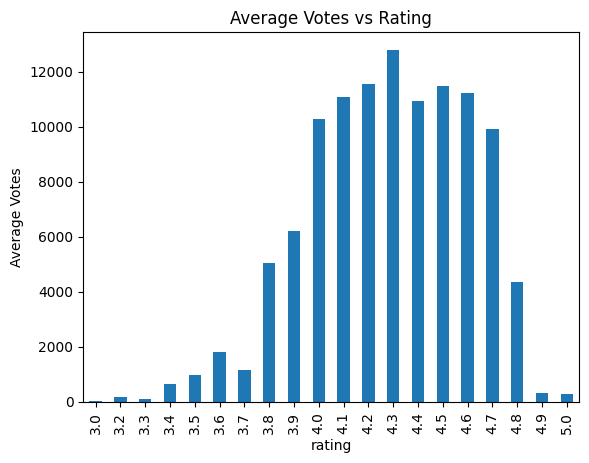

In [48]:
#Votes vs Rating Relationship
df.groupby("rating")["votes"].mean().plot(
    kind="bar",
    title="Average Votes vs Rating"
)

plt.ylabel("Average Votes")
plt.show()

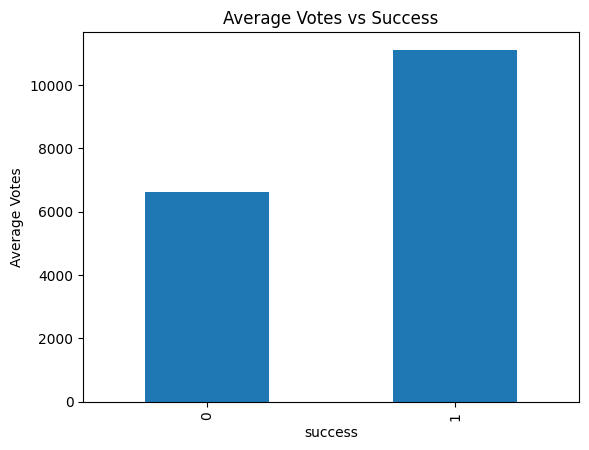

In [49]:
#Votes vs Success Relationship
df.groupby("success")["votes"].mean().plot(
    kind="bar",
    title="Average Votes vs Success"
)

plt.ylabel("Average Votes")
plt.show()

# Feature Engineering

In [50]:
# null value handling- rating will fill with median as rating is slightly left skewed
df = df.copy()
df['rating'] = df['rating'].fillna(df['rating'].median())

<Axes: ylabel='votes_log'>

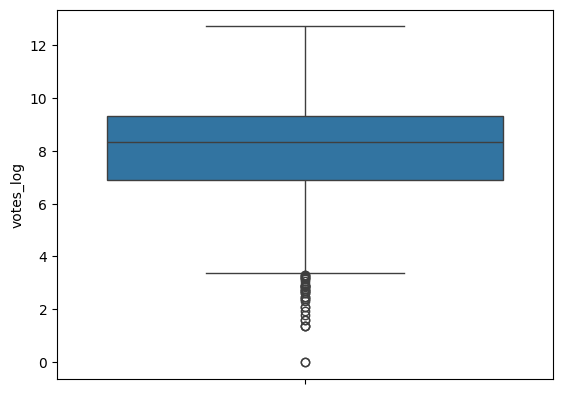

In [51]:
# outlier handling- votes highly right skewed hence will log transform,
# price will leave as it is without loosing actual meaning-not highly skewed like votes and few in number model can handle it
df['votes_log'] = np.log1p(df['votes'])
sns.boxplot(y=df['votes_log'])

Cuisines since many in number and is multilabelled we select only top 10 cuisines and manually do onehot encoding.

In [52]:
top_cuisines=df['cuisine'].str.split(",").explode().str.strip().value_counts().head(10).index
top_cuisines

Index(['Desserts', 'Beverages', 'Snacks', 'Chinese', 'North Indian', 'Biryani',
       'Fast Food', 'Bakery', 'Ice Cream', 'Burgers'],
      dtype='object', name='cuisine')

In [53]:
for cuisine in top_cuisines:

    df[cuisine] = df['cuisine'].apply(
        lambda x: 1 if cuisine in [c.strip() for c in str(x).split(",")] else 0
    )

In [54]:
df['cuisine_other'] = df['cuisine'].apply(
    lambda x: 1 if any(
        c.strip() not in top_cuisines
        for c in str(x).split(",")
    ) else 0
)

In [55]:
df['area'].value_counts()

,count
area,
Whitefield,38
Mysore South,36
Jayanagar,34
Gachibowli,33
Indiranagar,31
...,...
Opposite Infosys Kulathoor,1
Kuravankonam,1
Anayara,1


In [56]:
df_feat=df.copy()

In [57]:
df['price_for_two'].value_counts()

,count
price_for_two,
400,591
200,468
250,413
300,342
350,314
500,188
600,127
150,98
700,63


In [58]:
def price_bucket(price):

    if price <= 200:
        return "Low"

    elif (price>200 and price <= 600):
        return "Medium"

    elif (price>600 and price <= 1000):
        return "High"

    else:
        return "Luxury"


df_feat['price_bucket'] = df_feat['price_for_two'].apply(price_bucket)

In [59]:
tier_1_cities=["mumbai","delhi","bangalore","chennai","hyderabad","pune","kolkata"]
tier_2_cities=["ahmedabad","jaipur","kochi","trivandrum","mysore","coimbatore"]

In [60]:
#just dividing them to different sections as easier
def city_tier(city):
        if city in tier_1_cities:
            return 1
        elif city in tier_2_cities:
            return 2
        else:
            return 3

In [61]:
df_feat['city_tier']=df_feat['city'].apply(city_tier)

In [62]:
area_counts = df_feat['area'].value_counts()

df_feat['restaurant_density'] = df_feat['area'].map(

    lambda x:
        "High" if area_counts[x] >= 16
        else "Medium" if area_counts[x] > 8 and area_counts[x] <16
        else "Low"

)

In [63]:
# drop votes as log transformed hence votes column not needed for training only while deployment needed where it will still be in the data
df_feat=df_feat.drop(columns=['name','votes','cuisine','city','area','price_for_two','rating',])[['cuisine_count','has_online_delivery','votes_log','Desserts', 'Beverages', 'Snacks', 'Chinese', 'North Indian', 'Biryani',
       'Fast Food', 'Bakery', 'Ice Cream', 'Burgers','price_bucket','city_tier','restaurant_density','cuisine_other','success']]

In [64]:
df_feat.sample(5)

,cuisine_count,has_online_delivery,votes_log,Desserts,Beverages,Snacks,Chinese,North Indian,Biryani,Fast Food,Bakery,Ice Cream,Burgers,price_bucket,city_tier,restaurant_density,cuisine_other,success
1186,5,1,8.160804,0,1,0,1,0,0,0,0,0,0,Medium,1,Medium,1,1
5581,3,1,8.936035,0,0,0,0,0,1,0,0,0,0,Medium,1,Low,1,1
1082,3,1,4.127134,1,0,0,0,0,0,0,1,1,0,Low,1,Medium,0,1
7180,5,1,6.259581,1,0,0,0,0,0,0,0,0,0,Luxury,1,Medium,1,1
7801,1,1,10.239996,0,0,0,0,0,0,0,0,0,0,Low,3,Low,1,1


In [65]:
df_feat.shape

(2944, 18)

# Preprocessing

In [66]:
X= df_feat.drop('success',axis=1)
y= df_feat['success']

In [67]:
# city tier shd be onehot encoded else each tier will be treated mathematically big than other if simply scaled and hence distort predictions
# price bucket if done ordinal encoding will mean lower price restaurants are not eligible for good rating and mislead models like linear regression
# for tree based models it does not affect as it only groups so later if needed can improve with ordinal
# similarly for restuarant_density
# label encoding used only for target
# binary cols need not scale only if continuous can scale

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder

binary_cols=['has_online_delivery','cuisine_other']+ list(top_cuisines)

numerical_cols=['cuisine_count','votes_log']

categorical_cols=['city_tier']

ordinal_cols=['price_bucket','restaurant_density']

preprocessor= ColumnTransformer(transformers=[
    ("binary","passthrough",binary_cols),
    ("num",StandardScaler(),numerical_cols),
    ("cat",OneHotEncoder(drop='first',handle_unknown='ignore'),categorical_cols),#if unknown category entered
    ("ord",OrdinalEncoder(categories=[['Low','Medium','High','Luxury'],['Low','Medium','High']]),ordinal_cols)
])

In [69]:
x_clean= preprocessor.fit_transform(X)
columns = preprocessor.get_feature_names_out()
# Remove prefixes
clean_columns = [
    col.split("__")[1]
    for col in columns
]
df_clean = pd.DataFrame(x_clean,columns=clean_columns)
df_clean["success"] = y.values
df_clean.to_csv(
    "swiggy_clean_dataset_final.csv",
    index=False
)
df_clean.head()

,has_online_delivery,cuisine_other,Desserts,Beverages,Snacks,Chinese,North Indian,Biryani,Fast Food,Bakery,Ice Cream,Burgers,cuisine_count,votes_log,city_tier_2,city_tier_3,price_bucket,restaurant_density,success
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.500957,1.012730,0.0,0.0,1.0,2.0,1
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.965278,1.791052,0.0,0.0,1.0,2.0,1
2,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.106080,1.065765,0.0,0.0,1.0,2.0,1
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.429599,0.206959,0.0,0.0,1.0,0.0,1
4,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.106080,1.522601,0.0,0.0,1.0,0.0,1


In [70]:
# not using x_clean for training as x_clean is done for full X data including test which affects the splitting and preprocessing causing data leakage in training so doing splitting on original X
# the other is just for submission purpose
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (2355, 17)
Test set: (589, 17)


# Model Selection and Evaluation

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight='balanced'))
])

pipe_knn = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

pipe_svr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(class_weight='balanced'))
])

pipe_dt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(class_weight='balanced'))
])

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight='balanced',random_state=42))
])

pipe_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier())
])

pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(class_weight='balanced'))
])

In [72]:
import warnings
warnings.filterwarnings("ignore")

In [73]:
pipe_lr.fit(X_train, y_train)
pipe_knn.fit(X_train, y_train)
pipe_svr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_gb.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['has_online_delivery',
                                                   'cuisine_other', 'Desserts',
                                                   'Beverages', 'Snacks',
                                                   'Chinese', 'North Indian',
                                                   'Biryani', 'Fast Food',
                                                   'Bakery', 'Ice Cream',
                                                   'Burgers']),
                                                 ('num', StandardScaler(),
                                                  ['cuisine_count',
                                                   'votes_log']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None, ...))])

In [74]:
y_pred_lr = pipe_lr.predict(X_test)
y_pred_knn = pipe_knn.predict(X_test)
y_pred_svc = pipe_svr.predict(X_test)
y_pred_dt = pipe_dt.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)
y_pred_gb = pipe_gb.predict(X_test)
y_prob = pipe_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob > 0.7).astype(int)

In [75]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

a_lr=accuracy_score(y_test,y_pred_lr)
a_knn=accuracy_score(y_test,y_pred_knn)
a_svc=accuracy_score(y_test,y_pred_svc)
a_dtc=accuracy_score(y_test,y_pred_dt)
a_rfc=accuracy_score(y_test,y_pred_rf)
a_gb=accuracy_score(y_test,y_pred_gb)
a_xgb=accuracy_score(y_test,y_pred_xgb)

p_lr=precision_score(y_test,y_pred_lr)
p_knn=precision_score(y_test,y_pred_knn)
p_svc=precision_score(y_test,y_pred_svc)
p_dtc=precision_score(y_test,y_pred_dt)
p_rfc=precision_score(y_test,y_pred_rf)
p_gb=precision_score(y_test,y_pred_gb)
p_xgb=precision_score(y_test,y_pred_xgb)

r_lr=recall_score(y_test,y_pred_lr)
r_knn=recall_score(y_test,y_pred_knn)
r_svc=recall_score(y_test,y_pred_svc)
r_dtc=recall_score(y_test,y_pred_dt)
r_rfc=recall_score(y_test,y_pred_rf)
r_gb=recall_score(y_test,y_pred_gb)
r_xgb=recall_score(y_test,y_pred_xgb)

f_lr=f1_score(y_test,y_pred_lr)
f_knn=f1_score(y_test,y_pred_knn)
f_svc=f1_score(y_test,y_pred_svc)
f_dtc=f1_score(y_test,y_pred_dt)
f_rfc=f1_score(y_test,y_pred_rf)
f_gb=f1_score(y_test,y_pred_gb)
f_xgb=f1_score(y_test,y_pred_xgb)

roc_lr=roc_auc_score(y_test,y_pred_lr)
roc_knn=roc_auc_score(y_test,y_pred_knn)
roc_svc=roc_auc_score(y_test,y_pred_svc)
roc_dtc=roc_auc_score(y_test,y_pred_dt)
roc_rfc=roc_auc_score(y_test,y_pred_rf)
roc_gb=roc_auc_score(y_test,y_pred_gb)
roc_xgb=roc_auc_score(y_test,y_pred_xgb)

results_df=pd.DataFrame({
    'Model':['Logistic Regression','KNN','SVC','Decision Tree','Random Forest','Gradient Boost','XG Boost'],
    'accuracy_score':[a_lr,a_knn,a_svc,a_dtc,a_rfc,a_gb,a_xgb],
    'precision':[p_lr,p_knn,p_svc,p_dtc,p_rfc,p_gb,p_xgb],
    'recall':[r_lr,r_knn,r_svc,r_dtc,r_rfc,r_gb,r_xgb],
    'f1 score':[f_lr,f_knn,f_svc,f_dtc,f_rfc,f_gb,f_xgb],
    'roc auc':[roc_lr,roc_knn,roc_svc,roc_dtc,roc_rfc,roc_gb,roc_xgb]

})

In [76]:
results_df

,Model,accuracy_score,precision,recall,f1 score,roc auc
0,Logistic Regression,0.738540,0.967059,0.745917,0.842213,0.688748
1,KNN,0.926995,0.940972,0.983666,0.961846,0.544465
2,SVC,0.823430,0.964657,0.842105,0.899225,0.697368
3,Decision Tree,0.899830,0.947273,0.945554,0.946412,0.591198
4,Random Forest,0.930390,0.944251,0.983666,0.963556,0.570780
5,Gradient Boost,0.930390,0.941176,0.987296,0.963685,0.546279
6,XG Boost,0.932088,0.950617,0.978221,0.964222,0.620690


- XG Boost is the best model as it has the highest accuracy score of 0.932088 which means the model has an accuracy of around 93% which is good.
- Precision implies when model says a restaurant is successful, it is correct ~95% of the time
- Recall score tells out of all truly successful restaurants, model identifies ~97% of them
- F1 score maintains a very strong balance of 0.96 between recommending successful restaurants and avoiding incorrect predictions
- Roc Auc score is the ability of model to distinguish successful and unsuccessful restaurants which is low 0.62 due the dataset which has ratings only in 3 to 5 range leading to class imbalance.

In [77]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred_xgb)

array([[ 10,  28],
       [ 12, 539]])

# Hyperparameter Tuning

In [78]:
param_dist = {
    'model__n_estimators': [300, 500, 800],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [4, 6, 8],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__gamma': [0, 0.1, 0.3],
    'model__min_child_weight': [1, 3, 5],
    'model__reg_alpha': [0, 0.1, 1],
    'model__reg_lambda': [1, 1.5, 2]
}

In [79]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('binary',
                                                                               'passthrough',
                                                                               ['has_online_delivery',
                                                                                'cuisine_other',
                                                                                'Desserts',
                                                                                'Beverages',
                                                                                'Snacks',
                                                                                'Chinese',
                                                                                'North '
                                                                                'Indian',
                                                                                'Biryani',
                                                                                'Fast '
                                                                                'Food',
                                                                                'Bakery',
                                                                                'Ice '
                                                                                'Cream',
                                                                                'Burgers']),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               ['cuisine_count',
                                                                                'votes_log']),
                                                                              ('cat',
                                                                               OneHotEncode...
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__gamma': [0, 0.1, 0.3],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [4, 6, 8],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [300, 500, 800],
                                        'model__reg_alpha': [0, 0.1, 1],
                                        'model__reg_lambda': [1, 1.5, 2],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [80]:
best_xgb = random_search.best_estimator_

print(random_search.best_params_)

{'model__subsample': 0.7, 'model__reg_lambda': 1.5, 'model__reg_alpha': 1, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__gamma': 0.3, 'model__colsample_bytree': 0.7}


In [81]:
y_pred_best = best_xgb.predict(X_test)

In [82]:
print("Tuned XG Boost")
print("accuracy_score:", accuracy_score(y_test, y_pred_best))
print("precision:", precision_score(y_test, y_pred_best))
print("recall score:", recall_score(y_test, y_pred_best))
print("f1 score:", f1_score(y_test, y_pred_best))
print("roc_auc_score",roc_auc_score(y_test,y_pred_best))

Tuned XG Boost
accuracy_score: 0.9354838709677419
precision: 0.9445407279029463
recall score: 0.9891107078039928
f1 score: 0.9663120567375887
roc_auc_score 0.5735027223230491


FEATURE IMPORTANCE ANALYSIS

In [83]:
# Get feature names after preprocessing
feature_names = pipe_xgb.named_steps['preprocessor'].get_feature_names_out()

In [84]:
# Get feature importance from Random Forest
importances = pipe_xgb.named_steps['model'].feature_importances_

In [85]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
7,binary__Biryani,0.166431
6,binary__North Indian,0.096366
16,ord__price_bucket,0.078023
10,binary__Ice Cream,0.056602
14,cat__city_tier_2,0.056313
4,binary__Snacks,0.055699
13,num__votes_log,0.055151
9,binary__Bakery,0.054706
11,binary__Burgers,0.054019
5,binary__Chinese,0.053855


The feature importance analysis shows that cuisine type,pricing,location and popularity are the most significant predictor of restaurant success. This indicates that no.of cuisines a restaurant offers and customer engagement strongly influence restaurant ratings.

In [86]:
import pickle
with open("restaurant.pkl","wb") as f:
  pickle.dump(pipe_xgb,f)